# 2D Computronium

Let's train a 2D computronium instance that functions as a low-light retina 
(scotopic vision). The main thing here is to make a solid implementation for 
the async generator video loader. 


In [174]:
# Import box
import os
import sys
import jax 
import jax.numpy as jnp


import numpy as np
import cv2
import av 
import concurrent.futures
import pydantic 

In [194]:
args = {
    'overfit': False, 
    'train_dir': '../dataset/k400/train', # dir with a bunch of mp4s
    'val_dir': '../dataset/k400/val', # dir with a bunch of mp4s
    'batch_size': 6,
    'test_modules': True, 
    'random_seed': 24, 
    'height_px': 480, 
    'width_px': 640,
}

# turn into namespace/pydantic object

class Args(pydantic.BaseModel):
    overfit: bool = False
    train_dir: str = '../dataset/k400/train'
    val_dir: str = '../dataset/k400/val'
    batch_size: int = 4
    test_modules: bool = True
    random_seed: int = 0
    height_px: int = 480
    width_px: int = 640

args = Args(**args)

## Data Loader
 - PyAv (`av`) for loading video. 
 - Video shape: `[frames, height, width, rgb]`. To match the `batch channel height width` convention in JAX, we will have to transpose with `jnp.transpose(0, 3, 1, 2)`. 
 - We will `yield` a tensor of shape `[batch, frames, rgb, height, width]`. 


In [195]:
def rescale_frame(frame, height_width): 
    """
    frame: numpy array of shape [height, width, channel]
    height_width: tuple of (height, width)
    """
    # what is the scale factor for height and width? 
    hf, wf = frame.shape[:2] # height fo frame, width of frame
    hd, wd = height_width # height of desired, width of desired

    # print("hf, wf, hd, wd", hf, wf, hd, wd)

    # if hf/hd > wf/wd: 
    if hd / hf < wd / wf:
        # scale by width 
        scale = wd/wf
        frame_ = cv2.resize(frame, (int(wf*scale), int(hf*scale)))
        # print("Scaled frame size: ", frame_.shape)
        # crop to height 
        h = frame_.shape[0]
        frame_ = frame_[(h-hd)//2:(h+hd)//2, :]
        # print("Cropped frame size: ", frame_.shape)
        
    else:
        # scale by height 
        scale = hd/hf
        frame_ = cv2.resize(frame, (int(wf*scale), int(hf*scale)))
        # crop to width  
        w = frame_.shape[1]
        frame_ = frame_[:, (w-wd)//2:(w+wd)//2]
    return frame_

In [196]:
# def load_video(video_path):
#     with av.open(video_path) as container:
#         frames = []
#         for frame in container.decode(video=0):
#             frame = frame.to_ndarray(format='rgb24')
#             frames.append(frame)
#     return np.stack(frames)

def load_video(video_path):
    """ Function to load a video from a given path using pyav.

    Returns numpy array of shape [num_frames, height, width, channels]
    """
    with av.open(video_path) as container:
        frames = []
        for frame in container.decode(video=0):
            frame = frame.to_ndarray(format='rgb24')
            frames.append(frame)
    return np.stack(frames)

def async_video_loader(video_paths, num_workers, rescale=[240, 360]):
    """ Given a set of video paths, number of workers, and a rescale factor, 
    this function returns a numpy stack of video data of shape [num_videos,
    num_frames, height, width, channels] using a ThreadPoolExecutor with
    num_workers to load the videos in parallel with pyav. 

    The videos are rescaled to the desired height and width, and cropped to the
    minimum length of all videos in the batch.
    """
    with concurrent.futures.ThreadPoolExecutor(num_workers) as executor:
        futures = [executor.submit(load_video, path) for path in video_paths]
        results = [future.result() for future in concurrent.futures.as_completed(futures)]
    # check for shortest video 
    # print("Cropping videos in batch to min size...")
    # print("Type of results: ", type(results))
    # print("Type of results[0]: ", type(results[0]))
    for i in range(len(results)):
        # reshape to rescale
        # results[i] = np.array([cv2.resize(frame, (rescale[1], rescale[0])) for frame in results[i]])
        # crop to size 
        results[i] = np.array([rescale_frame(frame, rescale) for frame in results[i]])
        
        # print("Shape of results[{i}]: ", results[i].shape)

    min_length = min(video.shape[0] for video in results)
    print("min length: ", min_length)
    results = [video[:min_length] for video in results]
    return np.stack(results)

def video_data_generator(video_paths, batch_size, num_workers=4, rescale=[240, 360]):
    """ Given a list of mp4 video paths, a batch size, num_workers, and a video rescale size, 
    this provides an asynchronous multi-threaded generator that yields batches of video data 
    as jax.numpy arrays of shape [num_frames, batch_size, channels, height, width].
    """
    num_videos = len(video_paths)
    for i in range(0, num_videos, batch_size):
        batch_paths = video_paths[i:i+batch_size]
        # batch_data = [load_video(path) for path in batch_paths]
        batch_data = async_video_loader(batch_paths, num_workers=num_workers, rescale=rescale)
        # comes ouot as [batch_size, num_frames, height, width, channels]
        # reorg to [num_frames, batch_size, channels, height, width]
        batch_data = np.transpose(batch_data, (1, 0, 4, 2, 3))
        yield jnp.array(batch_data)


In [203]:
train_mp4s = [os.path.join(args.train_dir, f) for f in os.listdir(args.train_dir) if f.endswith('.mp4')]
train_mp4s = sorted(train_mp4s)



# random seed for jnp and np 
# args.random_seed=4
np.random.seed(args.random_seed)
# numpy shuffle trained_mp4s
np.random.shuffle(train_mp4s)
# print("First few train_mp4s: ", train_mp4s[:5])

val_mp4s = [os.path.join(args.val_dir, f) for f in os.listdir(args.val_dir) if f.endswith('.mp4')]
val_mp4s = sorted(val_mp4s)
# shuffle val 
np.random.shuffle(val_mp4s)

# overfit test
if args.overfit:
    train_mp4s = train_mp4s[:10]
    val_mp4s = val_mp4s[:2]

# now we can iterate thru video_data_generator(train_mp4s, args.batch_size) 
# to get our training data!

In [204]:
# show the first 5 frames from the first video
if args.test_modules:
    for i, batch in enumerate(video_data_generator(train_mp4s, args.batch_size, rescale=[args.height_px, args.width_px])):
        print(batch.shape)
        print("Dtype of batch: ", batch.dtype)
        print("Shape of batch: ", batch.shape) # [num_frames, batch_size, channels, height, width]
        break

min length:  151
(151, 6, 3, 480, 640)
Dtype of batch:  uint8
Shape of batch:  (151, 6, 3, 480, 640)


Batch size:  6
batch shape:  (151, 6, 3, 480, 640)


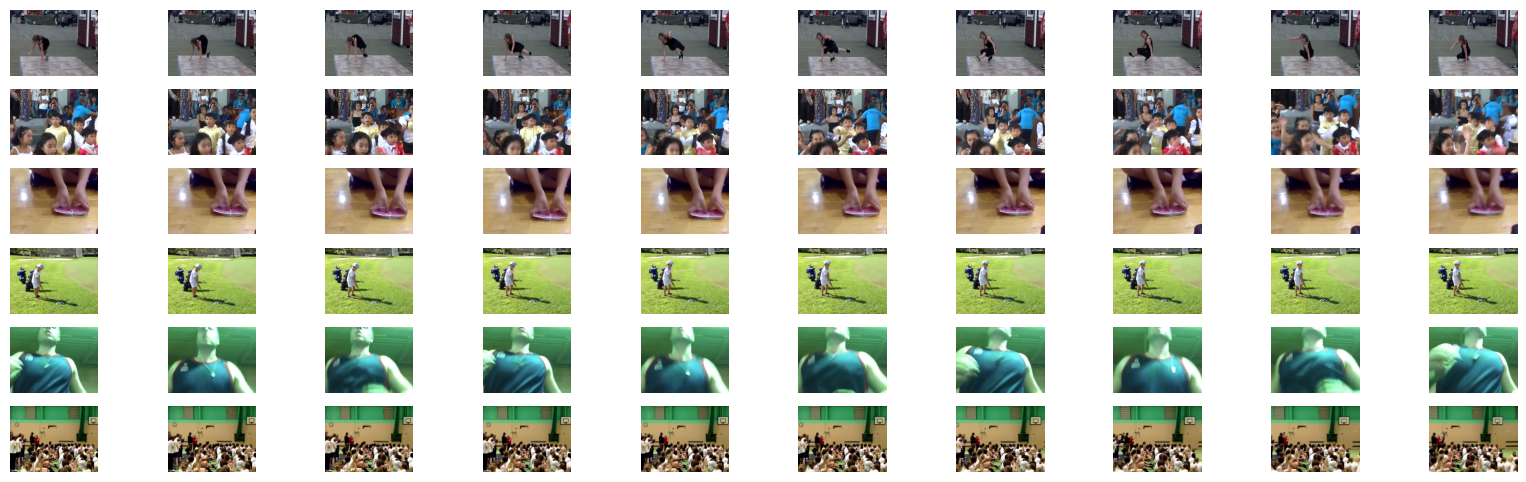

In [205]:
if args.test_modules:
    h_w_rgb_frame = batch[1, 50, :, :, :] # batch, frame, height, width, rgb 
    # plot 
    import matplotlib.pyplot as plt
    # plt.imshow(h_w_rgb_frame)


    # grid of 3x10 frames, 3 rows, 10 columns, one row per batch element and 10 frames per batch element (evenly spaced)
    print("Batch size: ", args.batch_size)
    print("batch shape: ", batch.shape)
    assert batch.shape[1] == args.batch_size
    fig, ax = plt.subplots(args.batch_size, 10, figsize=(20, 6))
    for i in range(args.batch_size):
        for j in range(10):
            # batch has shape [num_frames, batch_size, channels, height, width]
            # we gotta visualize [height, width, channels] with imshow
            ax[i, j].imshow(batch[j*5, i, :, :, :].transpose(1, 2, 0))
            ax[i, j].axis('off')
    # save ultra high res pic in case we need it
    plt.savefig('video_data.png', dpi=300)
    plt.show()

In [207]:
# get a list of all the num frames in each mp4 
num_frames = []
frame_dict = {}
from tqdm import tqdm
cnt=0
for mp4 in tqdm(train_mp4s):
    cnt += 1 
    if cnt > 2000: 
        break
    try: 
        with av.open(mp4) as container:
            num_frames.append(container.streams.video[0].frames)
            frame_dict[mp4] = {"num_frames: ": container.streams.video[0].frames}
    except Exception as e: 
        print("Error with mp4: ", mp4)
        num_frames.append(-1)
        frame_dict[mp4] = {"num_frames": -1, "note": f"Error: {e}"}
# histogram of num frames: 
import matplotlib.pyplot as plt
plt.hist(num_frames, bins=100)

  0%|          | 132/241258 [00:00<21:33, 186.41it/s]

Error with mp4:  ../dataset/k400/train/74TxD0ZZuOk_000115_000125.mp4


  0%|          | 242/241258 [00:01<24:20, 164.98it/s]

Error with mp4:  ../dataset/k400/train/nZbJiVtqzXo_000000_000010.mp4


  0%|          | 371/241258 [00:02<24:27, 164.10it/s]

...

  4%|▍         | 10558/241258 [01:09<23:42, 162.17it/s]

Error with mp4:  ../dataset/k400/train/mjsW4djX6xA_000053_000063.mp4


  4%|▍         | 10681/241258 [01:10<24:30, 156.75it/s]

Error with mp4:  ../dataset/k400/train/MVZlxI4ZI4k_000204_000214.mp4
Error with mp4:  ../dataset/k400/train/9qXwehMoX7o_000057_000067.mp4


  5%|▍         | 10904/241258 [01:11<25:35, 150.06it/s]